In [ ]:
marks = [ 45, 60, 72, 38, 90]

In [ ]:
total = 0
for i in range(len(marks) - 1):
  total += marks[i]

average = total / len(marks)
if average > 50:
  print("Class passed")
else:
  print("Class failed")

print("Average: ", average)


Class failed
Average:  43.0


In [ ]:
import pandas as pd

In [ ]:
data = {
    "student_id": [101,102,103,104,105,106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

In [ ]:

df = pd.DataFrame(data)

In [ ]:
df


,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True
5,106,88,19,80,True


In [ ]:
df.shape

(6, 5)

In [ ]:
df.head()

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


In [ ]:
df.describe()

,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [ ]:
df['total_score'] = df['assignment_score'] + df['quiz_score']


In [ ]:
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score
0,101,92,18,72,True,90
1,102,67,12,48,False,60
2,103,81,15,65,True,80
3,104,45,8,30,False,38
4,105,74,14,55,True,69
5,106,88,19,80,True,99


In [ ]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)


In [ ]:
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [ ]:
eligible_students = df[df["eligible"] == True]

In [ ]:
eligible_students

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
display(df)

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [ ]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)

In [22]:
df


,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [23]:

eligible_students = df[df["eligible"] == True]

eligible_students


,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


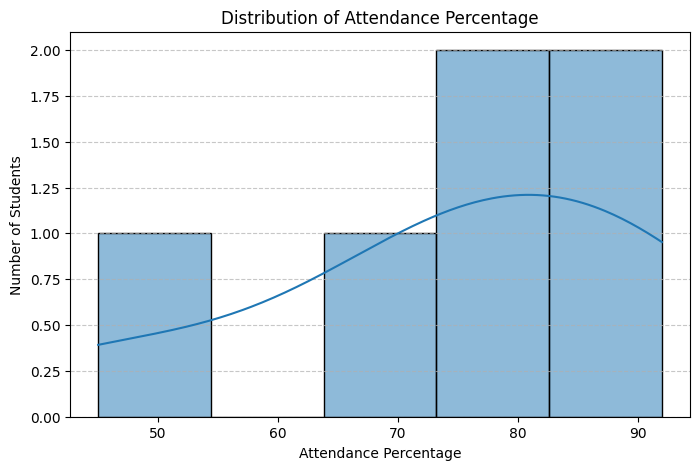

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(df['attendance_percent'], bins=5, kde=True)
plt.title('Distribution of Attendance Percentage')
plt.xlabel('Attendance Percentage')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

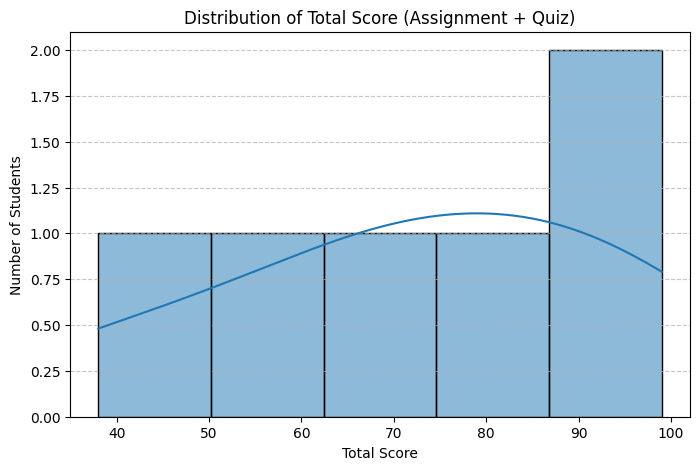

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(df['total_score'], bins=5, kde=True)
plt.title('Distribution of Total Score (Assignment + Quiz)')
plt.xlabel('Total Score')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [26]:

def assign_grade(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    elif score >= 70:
        return 'C'
    elif score >= 60:
        return 'D'
    else:
        return 'F'

In [27]:
df['grade_category'] = df['total_score'].apply(assign_grade)


In [28]:
def assign_attendance_status(percent):
    if percent >= 90:
        return 'Excellent'
    elif percent >= 75:
        return 'Good'
    elif percent >= 60:
        return 'Average'
    else:
        return 'Poor'


In [29]:

df['attendance_status'] = df['attendance_percent'].apply(assign_attendance_status)



In [30]:
display(df)

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible,grade_category,attendance_status
0,101,92,18,72,True,90,True,A,Excellent
1,102,67,12,48,False,60,False,D,Average
2,103,81,15,65,True,80,True,B,Good
3,104,45,8,30,False,38,False,F,Poor
4,105,74,14,55,True,69,False,D,Average
5,106,88,19,80,True,99,True,A,Good


/tmp/ipykernel_8253/4014384287.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='grade_category', data=df, order=['A', 'B', 'C', 'D', 'F'], palette='viridis')


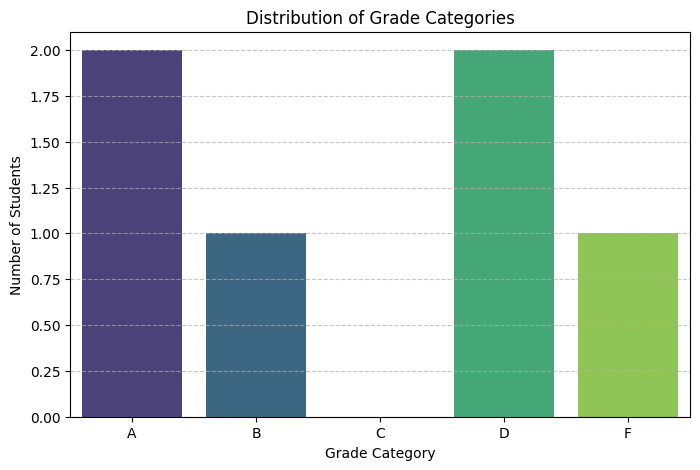

In [31]:
plt.figure(figsize=(8, 5))
sns.countplot(x='grade_category', data=df, order=['A', 'B', 'C', 'D', 'F'], palette='viridis')
plt.title('Distribution of Grade Categories')
plt.xlabel('Grade Category')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_8253/1969513808.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='attendance_status', data=df, order=['Excellent', 'Good', 'Average', 'Poor'], palette='magma')


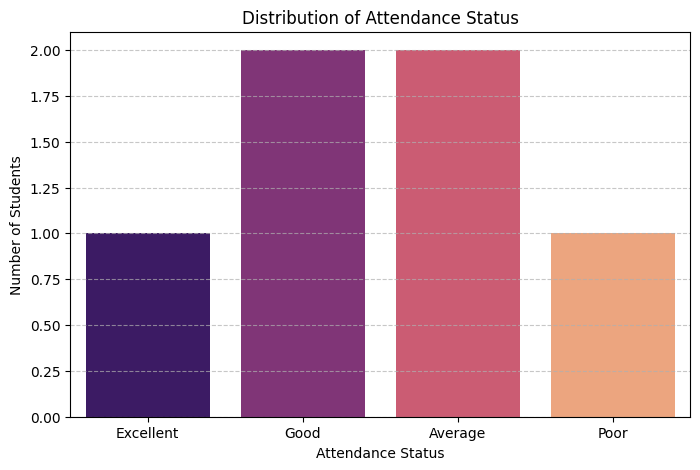

In [32]:
plt.figure(figsize=(8, 5))
sns.countplot(x='attendance_status', data=df, order=['Excellent', 'Good', 'Average', 'Poor'], palette='magma')
plt.title('Distribution of Attendance Status')
plt.xlabel('Attendance Status')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
